<a href="https://colab.research.google.com/github/prodigal94/food-safe-bots/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
!pip install pyspark

In [25]:
from pyspark.sql import functions as F
from pyspark.sql.types import *
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [26]:
# Initialize Spark with optimizations for large data
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("BDA_Project") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()

In [48]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
### CSV
#file_path = '/content/drive/MyDrive/CSV/Trade_CropsLivestock_E_All_Data_(Normalized).csv'
#df = spark.read.csv(file_path, header=True, inferSchema=True)

### PARQUITE
file_path = '/content/drive/MyDrive/Parquet/00_AgriTrade_Dataset_BigData.parquet'
df = spark.read.parquet(file_path)

In [38]:
df_before = df  # This is just a reference, not a copy

In [39]:
# Cache the dataframe to avoid recomputation
df.cache()

total_records = df.count()
print(f"Total records: {total_records:,}")
print(f"Total columns: {len(df.columns)}")

Total records: 3,744,278
Total columns: 14


In [40]:
print("\n--- WHOLE DATASET MISSING VALUES (BEFORE CLEANING) ---")

total_before = df_before.count()

rows_with_missing_before = df_before.filter(
    F.greatest(*[F.when(F.col(c).isNull(), 1).otherwise(0) for c in df_before.columns]) == 1
).count()

rows_complete_before = total_before - rows_with_missing_before

print("Total rows:", total_before)
print("Rows with at least one missing value:", rows_with_missing_before)
print("Complete rows:", rows_complete_before)
print("Percent with missing:", round((rows_with_missing_before / total_before) * 100, 2), "%")



--- WHOLE DATASET MISSING VALUES (BEFORE CLEANING) ---
Total rows: 3744278
Rows with at least one missing value: 3326134
Complete rows: 418144
Percent with missing: 88.83 %


In [41]:
# Get year range
min_year = df.select(F.min('Year')).collect()[0][0]
max_year = df.select(F.max('Year')).collect()[0][0]
print(f"Year range: {min_year} - {max_year}")

Year range: 1961 - 2024


In [42]:
# Check duplicates BEFORE
print("\n--- Duplicate Records (BEFORE) ---")
duplicates_before = total_records - df.distinct().count()
print(f"Duplicate rows: {duplicates_before:,}")


--- Duplicate Records (BEFORE) ---
Duplicate rows: 0


In [ ]:
# EDA 1: TOTAL TRADE ITEMS (ALL PRODUCTS TOGETHER - RECORD COUNTS ONLY)
print("\n" + "=" * 60)
print("EDA 1: COUNT FOR EACH TRADE ITEM (ALL PRODUCTS)")
print("=" * 60)

# Show total distinct trade items
distinct_items = df_before.select("Item").distinct().count()
print(f"\n TOTAL DISTINCT TRADE ITEMS: {distinct_items:,}")
print(f" TOTAL RECORDS: {df_before.count():,}")

# Count for each trade item (ALL items together) - NO VALUE
item_counts_before = df_before.groupBy("Item").agg(
    F.count("*").alias("Record_Count")
).orderBy(F.desc("Record_Count"))

print("\n TOP 20 ITEMS BY RECORD COUNT (ALL PRODUCTS TOGETHER):")
item_counts_before.show(20, truncate=False)

# Collect for visualization (top 15 for better view)
item_top_list = item_counts_before.limit(15).collect()
items_top = [row.Item for row in item_top_list]
counts_top = [row.Record_Count for row in item_top_list]

# VISUALIZATION
plt.figure(figsize=(12, 8))

plt.barh(items_top, counts_top, color='steelblue', edgecolor='black')
plt.title('Top 15 Trade Items by Record Count\n(All Crops & Livestock Products Together)',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Records', fontsize=12)
plt.ylabel('Trade Item', fontsize=12)

# Add value labels
for i, v in enumerate(counts_top):
    plt.text(v + 1000, i, f'{v:,}', va='center', fontsize=9)

plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# Simple summary
print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)
print(f"Total Distinct Items: {distinct_items:,}")
print(f"Total Records: {df_before.count():,}")
print(f"Average Records per Item: {df_before.count() / distinct_items:,.1f}")

# Most and least frequent items
print(f"\nMost frequent item: {item_counts_before.first()['Item']} ({item_counts_before.first()['Record_Count']:,} records)")
least_frequent = item_counts_before.orderBy(F.asc("Record_Count")).filter(F.col("Record_Count") > 0).first()
print(f"Least frequent item: {least_frequent['Item']} ({least_frequent['Record_Count']:,} records)")

In [ ]:
### EDA 3: Line Plot for Global Trade BEFORE PROCESSING, Using Area Code 5000, 'World'

### USD
world_trade_usd_df = df_before.filter((df_before['Area Code'] == 5000) & (df_before['Unit'] == '1000 USD')) \
  .groupBy('Year').sum('Value').withColumnRenamed('sum(Value)', 'Total Trade (USD)') \
  .orderBy('Year', ascending=False)

sns.set(style='white')

plot_data = world_trade_usd_df.select('Year', 'Total Trade (USD)') \
  .orderBy('Year') \
  .collect()
years = [row['Year'] for row in plot_data]
total_trade = [row['Total Trade (USD)'] / 1_000_000 for row in plot_data]

plt.plot(years, total_trade)
plt.title('Global Trade in Million USD (1961-2024)')
plt.xlabel('Year')
plt.ylabel('Total Trade (Million USD)')
plt.grid(True)
plt.show()

### Tonnes
world_trade_tonnes_df = df_before.filter((df_before['Area Code'] == 5000) & (df_before['Unit'] == 't')) \
  .groupBy('Year').sum('Value').withColumnRenamed('sum(Value)', 'Total Trade (tonnes)') \
  .orderBy('Year', ascending=False)

plot_data = world_trade_tonnes_df.select('Year', 'Total Trade (tonnes)') \
  .orderBy('Year') \
  .collect()
years = [row['Year'] for row in plot_data]
total_trade = [row['Total Trade (tonnes)'] / 1_000_000 for row in plot_data]

plt.plot(years, total_trade)
plt.title('Global Trade in Million tonnes (1961-2024)')
plt.xlabel('Year')
plt.ylabel('Total Trade (Million tonnes)')
plt.grid(True)
plt.show()

#world_trade_tonnes_df.show()
#print(world_trade_tonnes_df.count())

In [ ]:
# DATA CLEANING
print("\n" + "=" * 60)
print("DATA CLEANING")
print("=" * 60)

print("Rows before cleaning:", df_before.count())

# Filter using Area Code to only include individual Countries, removes Continents
# and trade groups (e.g. EU)
df = df.filter(df['Area Code'] < 500). \
  select("Area", "Item", "Element", "Year", "Unit", "Value", "Flag")

df = df.dropDuplicates()

df = df.dropna(subset=["Area", "Item", "Element", "Year", "Unit", "Value"])

df = df.filter(df.Value > 0)

df = df.orderBy("Area", "Item", "Year")

df_after = df

print("Rows after cleaning:", df_after.count())
print("Columns after cleaning:", len(df_after.columns))
df_after.show(5, truncate=False)


In [ ]:
save_path = "/content/drive/MyDrive/Parquet/AgriTrade_Cleaned.parquet"
df.write.format("parquet").save(save_path)

In [ ]:
### Check how much of the dataset already includes both the Value and Quantity
### of the trade.
print("=" * 60)
print("PAIRED AND MISSING RECORDS ANALYSIS")
print("=" * 60)

# Filter for relevant units
filtered_df = df.filter((F.col("Unit") == "1000 USD") | (F.col("Unit") == "t"))

# Group by identifier columns and pivot on 'Unit' to count occurrences
pivoted_df = filtered_df.groupBy("Area", "Item", "Year").pivot("Unit", ["1000 USD", "t"]).count()

# Fill nulls with 0 where a unit was not present in a group
pivoted_df = pivoted_df.na.fill(0)

# Identify complete pairs (both '1000 USD' and 't' counts are 1)
complete_pairs = pivoted_df.filter((F.col("1000 USD") == 1) & (F.col("t") == 1))
num_complete_pairs = complete_pairs.count()

# Identify missing pairs (only one unit is present, i.e., one count is 1 and the other is 0)
missing_pairs_usd = pivoted_df.filter((F.col("1000 USD") == 1) & (F.col("t") == 0))
missing_pairs_t = pivoted_df.filter((F.col("1000 USD") == 0) & (F.col("t") == 1))

num_missing_usd = missing_pairs_usd.count()
num_missing_t = missing_pairs_t.count()

print(f"Total distinct Area-Item-Year combinations with USD or t: {pivoted_df.count():,}")
print(f"Number of complete pairs (both '1000 USD' and 't' present): {num_complete_pairs:,}")
print(f"Number of missing pairs ('1000 USD' present, 't' missing): {num_missing_usd:,}")
print(f"Number of missing pairs ('t' present, '1000 USD' missing): {num_missing_t:,}")

print("\n" + "=" * 60)

In [ ]:
print("=" * 60)
print("REMOVING TRADE QUANTITY RECORDS")
print("=" * 60)

print("Rows before cleaning:", df.count())

df = df.filter(df['Unit'] == '1000 USD')

df_after = df

print("Rows after cleaning:", df_after.count())
print("Columns after cleaning:", len(df_after.columns))
df_after.show(5, truncate=False)

In [ ]:
save_path = "/content/drive/MyDrive/Parquet/02_AgriTrade_ValueOnly.parquet"
df.write.format("parquet").save(save_path)

In [ ]:
print("\n--- WHOLE DATASET MISSING VALUES (AFTER CLEANING) ---")

total_after = df_after.count()

rows_with_missing_after = df_after.filter(
    F.greatest(*[F.when(F.col(c).isNull(), 1).otherwise(0) for c in df_after.columns]) == 1
).count()

rows_complete_after = total_after - rows_with_missing_after

print("Total rows:", total_after)
print("Rows with at least one missing value:", rows_with_missing_after)
print("Complete rows:", rows_complete_after)
print("Percent with missing:", round((rows_with_missing_after / total_after) * 100, 2), "%")


In [ ]:
min_year_after = df_after.select(F.min('Year')).collect()[0][0]
max_year_after = df_after.select(F.max('Year')).collect()[0][0]
print(f"Year range after cleaning: {min_year_after} - {max_year_after}")


In [ ]:
### EDA 4: Global Trade in USD AFTER CLEANING, using Sum of Years
world_trade_usd_df = df_after.groupBy('Year') \
  .sum('Value').withColumnRenamed('sum(Value)', 'Total Trade (USD)') \
  .orderBy('Year', ascending=False)

sns.set(style='white')

plot_data = world_trade_usd_df.select('Year', 'Total Trade (USD)') \
  .orderBy('Year') \
  .collect()
years = [row['Year'] for row in plot_data]
total_trade = [row['Total Trade (USD)'] / 1_000_000 for row in plot_data]

plt.plot(years, total_trade)
plt.title('Global Trade in Million USD (1961-2024)')
plt.xlabel('Year')
plt.ylabel('Total Trade (Million USD)')
plt.grid(True)
plt.show()


In [ ]:
# EDA 2: TOTAL TRADE ITEMS AFTER CLEANING
print("\n" + "=" * 60)
print("EDA 2: COUNT FOR EACH TRADE ITEM (AFTER CLEANING)")
print("=" * 60)

distinct_items_after = df_after.select("Item").distinct().count()
print(f"\nTOTAL DISTINCT TRADE ITEMS: {distinct_items_after:,}")
print(f"TOTAL RECORDS: {df_after.count():,}")

item_counts_after = df_after.groupBy("Item").agg(
    F.count("*").alias("Record_Count")
).orderBy(F.desc("Record_Count"))

print("\nTOP 20 ITEMS BY RECORD COUNT:")
item_counts_after.show(20, truncate=False)

item_top_list_after = item_counts_after.limit(15).collect()
items_top_after = [row.Item for row in item_top_list_after]
counts_top_after = [row.Record_Count for row in item_top_list_after]

plt.figure(figsize=(12, 8))
plt.barh(items_top_after, counts_top_after, color='darkgreen', edgecolor='black')
plt.title('Top 15 Trade Items by Record Count\n(After Cleaning)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Records', fontsize=12)
plt.ylabel('Trade Item', fontsize=12)

for i, v in enumerate(counts_top_after):
    plt.text(v + 1000, i, f'{v:,}', va='center', fontsize=9)

plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


EDA Contribution: Import and Export Trade Value Distribution and Outlier Detection

EDA A: BEFORE PREPROCESSING - Import and Export Trade Value Distribution
Total records used for EDA A: 1358708


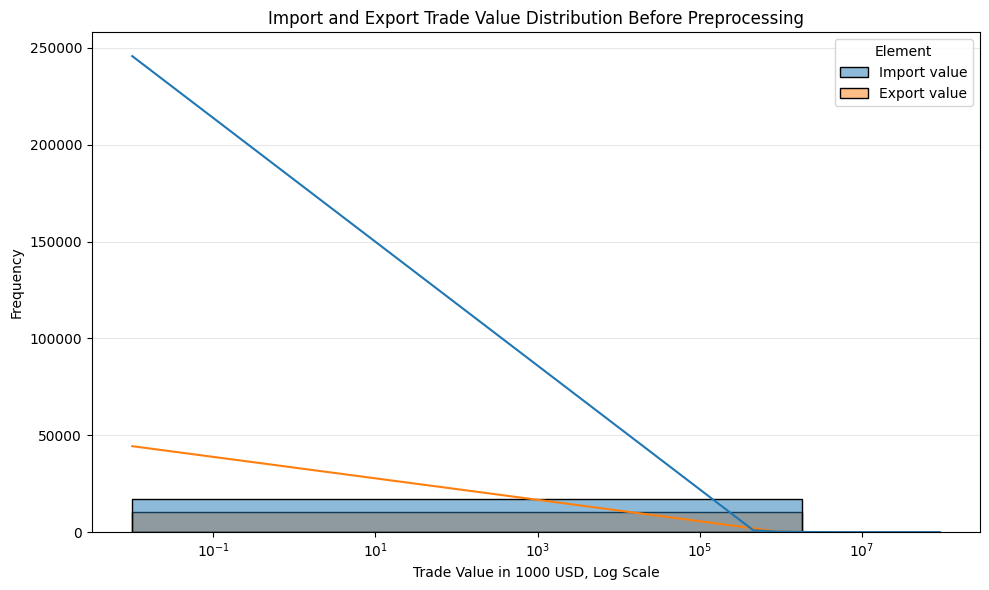

In [43]:
# BEFORE Preprocessing — Histogram of Import and Export Trade Values

print("=" * 70)
print("EDA A: BEFORE PREPROCESSING - Import and Export Trade Value Distribution")
print("=" * 70)

before_trade = df_before.filter(
    (F.col("Unit") == "1000 USD") &
    (F.col("Element").isin(["Import value", "Export value", "Import Value", "Export Value"])) &
    (F.col("Value").isNotNull()) &
    (F.col("Value") > 0)
).select("Element", "Value")

print("Total records used for EDA A:", before_trade.count())

before_trade_pd = before_trade.sample(False, 0.02, seed=42).toPandas()

plt.figure(figsize=(10, 6))
sns.histplot(
    data=before_trade_pd,
    x="Value",
    hue="Element",
    bins=50,
    kde=True
)

plt.xscale("log")
plt.title("Import and Export Trade Value Distribution Before Preprocessing")
plt.xlabel("Trade Value in 1000 USD, Log Scale")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The histogram shows the distribution of import and export trade values before preprocessing. Most records have low trade values, while only a few records have extremely high values. A log scale was used because the trade values vary widely. This graph shows the original distribution of the raw dataset before cleaning.

EDA B: BEFORE PREPROCESSING - Import and Export Outlier Detection
Total records used for EDA B: 1358708


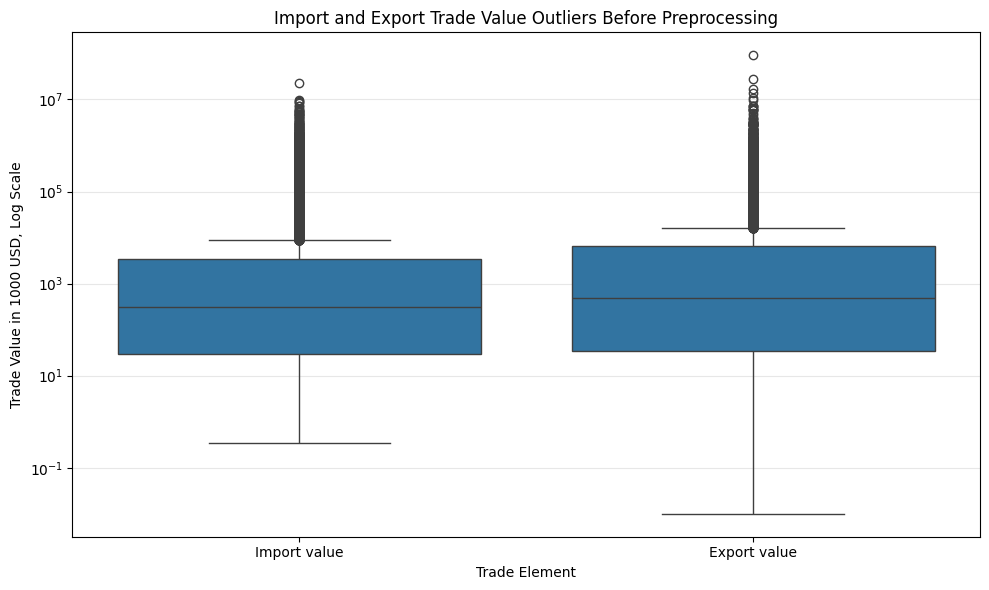

In [44]:
#BEFORE Preprocessing — Box Plot for Import and Export Outlier Detection

print("=" * 70)
print("EDA B: BEFORE PREPROCESSING - Import and Export Outlier Detection")
print("=" * 70)

before_boxplot = df_before.filter(
    (F.col("Unit") == "1000 USD") &
    (F.col("Element").isin(["Import value", "Export value", "Import Value", "Export Value"])) &
    (F.col("Value").isNotNull()) &
    (F.col("Value") > 0)
).select("Element", "Value")

print("Total records used for EDA B:", before_boxplot.count())

before_boxplot_pd = before_boxplot.sample(False, 0.02, seed=42).toPandas()

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=before_boxplot_pd,
    x="Element",
    y="Value"
)

plt.yscale("log")
plt.title("Import and Export Trade Value Outliers Before Preprocessing")
plt.xlabel("Trade Element")
plt.ylabel("Trade Value in 1000 USD, Log Scale")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The box plot shows possible outliers in import and export trade values before preprocessing. The points above the box represent unusually high trade values. Since this is before cleaning, some outliers may be caused by duplicates, aggregate areas, or inconsistent records.

EDA C: AFTER PREPROCESSING - Import and Export Trade Value Distribution
Total records used for EDA C: 4315401


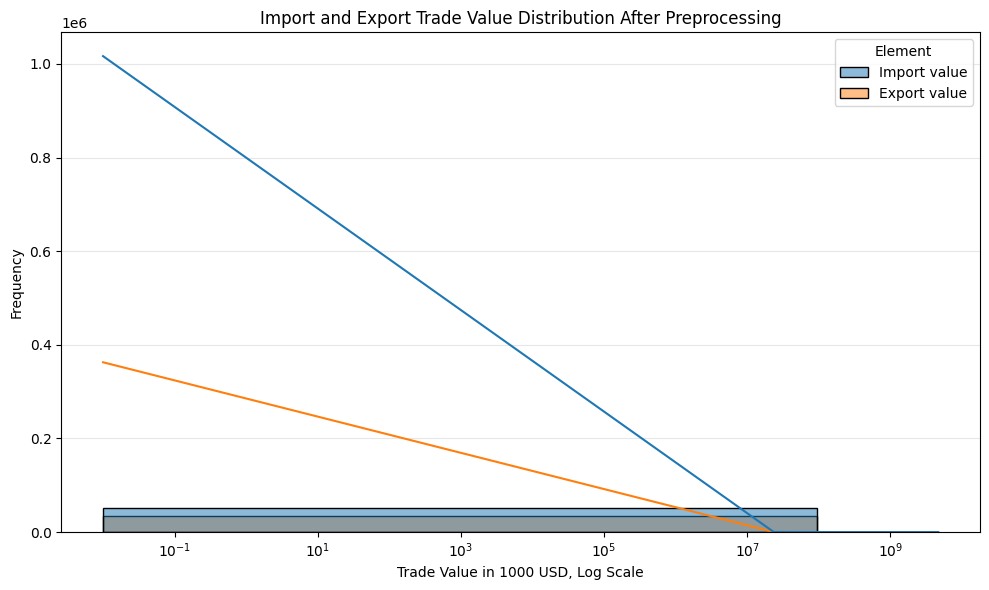

In [54]:
# AFTER Preprocessing — Histogram of Import and Export Trade Values

print("=" * 70)
print("EDA C: AFTER PREPROCESSING - Import and Export Trade Value Distribution")
print("=" * 70)

file_path = '/content/drive/MyDrive/Parquet/02_AgriTrade_ValueOnly.parquet'

df_after= spark.read.parquet(file_path)
after_trade = df_after.filter(
    (F.col("Unit") == "1000 USD") &
    (F.col("Element").isin(["Import value", "Export value", "Import Value", "Export Value"])) &
    (F.col("Value").isNotNull()) &
    (F.col("Value") > 0)
).select("Element", "Value")

print("Total records used for EDA C:", after_trade.count())

after_trade_pd = after_trade.sample(False, 0.02, seed=42).toPandas()

plt.figure(figsize=(10, 6))
sns.histplot(
    data=after_trade_pd,
    x="Value",
    hue="Element",
    bins=50,
    kde=True
)

plt.xscale("log")
plt.title("Import and Export Trade Value Distribution After Preprocessing")
plt.xlabel("Trade Value in 1000 USD, Log Scale")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The histogram shows the distribution of import and export trade values after preprocessing. Most records are still concentrated at lower values, but the dataset is now cleaner and more reliable because invalid, missing, duplicated, and unnecessary records have been removed.

EDA D: AFTER PREPROCESSING - Import and Export Outlier Detection
Total records used for EDA D: 4315401


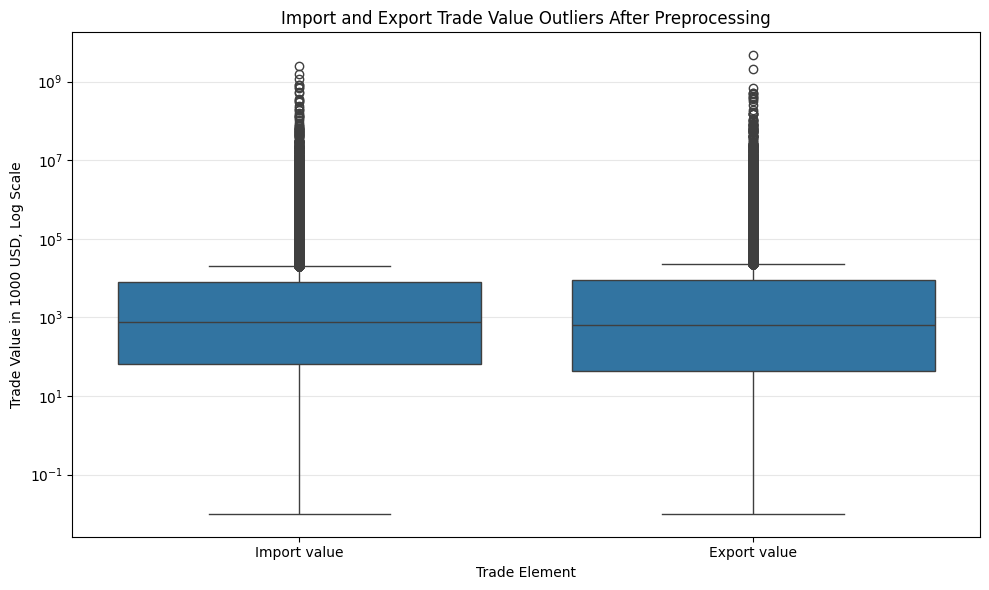

In [56]:
# AFTER Preprocessing — Box Plot for Import and Export Outlier Detection

print("=" * 70)
print("EDA D: AFTER PREPROCESSING - Import and Export Outlier Detection")
print("=" * 70)

after_boxplot = df_after.filter(
    (F.col("Unit") == "1000 USD") &
    (F.col("Element").isin(["Import value", "Export value", "Import Value", "Export Value"])) &
    (F.col("Value").isNotNull()) &
    (F.col("Value") > 0)
).select("Element", "Value")

print("Total records used for EDA D:", after_boxplot.count())

after_boxplot_pd = after_boxplot.sample(False, 0.02, seed=42).toPandas()

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=after_boxplot_pd,
    x="Element",
    y="Value"
)

plt.yscale("log")
plt.title("Import and Export Trade Value Outliers After Preprocessing")
plt.xlabel("Trade Element")
plt.ylabel("Trade Value in 1000 USD, Log Scale")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The box plot shows possible outliers in import and export trade values after preprocessing. These remaining outliers are more meaningful because the dataset has already been cleaned. They may represent countries or products with unusually high agricultural import or export activity.